In [110]:
'''
NAME: ADITYA AGRAWAL
ROLL: 2311010
ENDSEMS ARE HERE!
DATE-27/11/2025
'''

'\nNAME: ADITYA AGRAWAL\nROLL: 2311010\nENDSEMS ARE HERE!\nDATE-27/11/2025\n'

In [102]:
import sys
import matplotlib.pyplot as plt

sys.path.append('/Users/adityaagrawal/clonedrepo/COMPUTATIONAL_PHYSICS/LABWORK')

import adilib_class as ad
import math

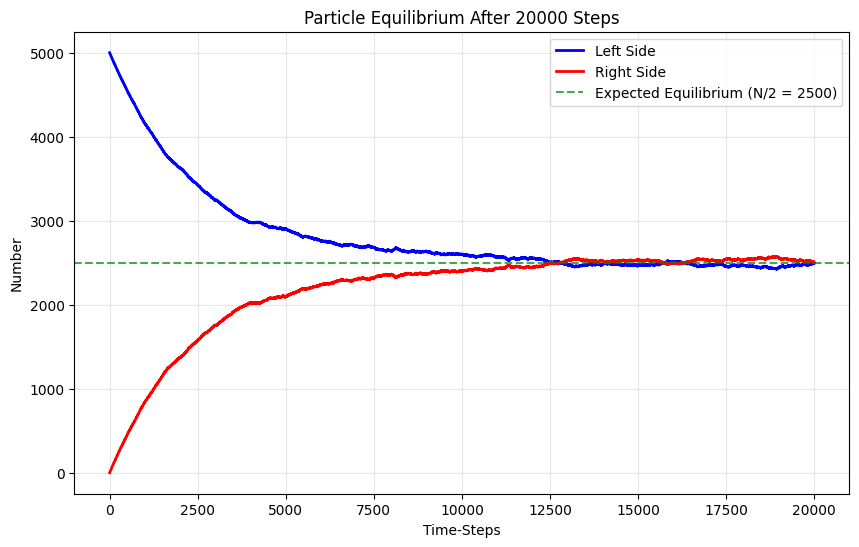

EQUILIBRIUM RESULTS:
Initial: Left=5000, Right=0
Final:   Left=2492, Right=2508
Expected: around2500 each side....hence quite good results!!


In [103]:
#question 1:
def particle_simulation(N=5000, time_steps=20000):
    left=N
    right=0
    time=[]
    left_particles=[]
    right_particles=[]
    
    random_nums = ad.RandomNumbers.pRNG_LCG(time_steps) #using own gen.

    for t in range(time_steps):
        if left > 0 and random_nums[t] < left/ N: 
            left-=1
            right+=1
        else:
            right-=1
            left+=1    
        time.append(t)
        left_particles.append(left)
        right_particles.append(right)
    return time, left_particles, right_particles


time, left_count, right_count=particle_simulation()

# plot!
plt.figure(figsize=(10,6))
plt.plot(time, left_count,'b-', label='Left Side', linewidth=2)
plt.plot(time, right_count,'r-', label='Right Side', linewidth=2)
plt.axhline(y=2500, color='green', linestyle='--', alpha=0.7, label='Expected Equilibrium (N/2 = 2500)')
plt.xlabel('Time-Steps')
plt.ylabel('Number')
plt.title('Particle Equilibrium After 20000 Steps')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# results
final_left=left_count[-1]
final_right=right_count[-1]
print(f"EQUILIBRIUM RESULTS:")
print(f"Initial: Left=5000, Right=0")
print(f"Final:   Left={final_left}, Right={final_right}")
print(f"Expected: around2500 each side....hence quite good results!!")

In [104]:
#question 2:
A=[4,-1,0,-1,0,0,   #define A
   -1,4,-1,0,-1,0,
   0,-1,4,0,0,-1,
   -1,0,0,4,-1,0,
   0,-1,0,-1,4,-1,
   0,0,-1,0,-1,4]

b=[2,1,2,2,1,2] #define b

n = len(b)
if isinstance(A, list) and len(A)==n*n and all(not isinstance(row, list) for row in A):
    A_mat = [A[i*n:(i+1)*n] for i in range(n)]
else:
    A_mat = A
x, iterations, errors= ad.LinearSystems.gauss_seidel_iteration(A_mat, b, 1e-6, 100)
print("The solution of the given linear equations is:")
print(x)
print(f"Number of iterations taken:{iterations}")
print("Done!")


Gauss-Seidel Iteration Method
Iter	x[0]	x[1]	x[2]	x[3]	x[4]	x[5]	Error
0	0.0000	0.0000	0.0000	0.0000	0.0000	0.0000	---
1	0.5000	0.3750	0.5938	0.6250	0.5000	0.7734	0.773438
2	0.7500	0.7109	0.8711	0.8125	0.8242	0.9238	0.335938
3	0.8809	0.8940	0.9545	0.9263	0.9360	0.9726	0.183105
4	0.9551	0.9614	0.9835	0.9728	0.9767	0.9901	0.074219
5	0.9835	0.9859	0.9940	0.9901	0.9915	0.9964	0.028465
6	0.9940	0.9949	0.9978	0.9964	0.9969	0.9987	0.010456
7	0.9978	0.9981	0.9992	0.9987	0.9989	0.9995	0.003814
8	0.9992	0.9993	0.9997	0.9995	0.9996	0.9998	0.001390
9	0.9997	0.9998	0.9999	0.9998	0.9999	0.9999	0.000506
10	0.9999	0.9999	1.0000	0.9999	0.9999	1.0000	0.000184
16	1.0000	1.0000	1.0000	1.0000	1.0000	1.0000	0.000000

Converged after 16 iterations.
The solution of the given linear equations is:
[0.9999997530614102, 0.9999997892247294, 0.9999999100460266, 0.9999998509593768, 0.9999998727858708, 0.9999999457079743]
Number of iterations taken:16
Done!


In [105]:
#question 3:
def force(x):      #F
    return 2.5 - x * math.exp(x)

def force_deriv(x):      #F-deriv.
    return -math.exp(x) - x * math.exp(x)

x_root, iterations = ad.Roots.NewtonRaphson(force, force_deriv,0.5,1e-6,50)
print(f"Spring can be stretched to: {x_root} meters")
print(f"Iterations: {len(iterations)}")

Total Iterations(new-raph):- 5 0.9585863567288397 
f(root=) -6.989964163039986e-13
Spring can be stretched to: 0.9585863567288397 meters
Iterations: 5


In [106]:
#question 4:
def mass_density(x): #given mass_density(lambda)
    return x**2

numerator_func = lambda x: x *mass_density(x)  #x*lambda(x)
denominator_func = lambda x: mass_density(x) #lambda(x)

numerator=ad.Integration.simpson( 0, 2, numerator_func,1000)
denominator=ad.Integration.simpson( 0, 2, denominator_func,1000)
center_of_mass=numerator/denominator

print(f"COM of beam: {center_of_mass:.4f} meters from one end")

COM of beam: 1.5000 meters from one end


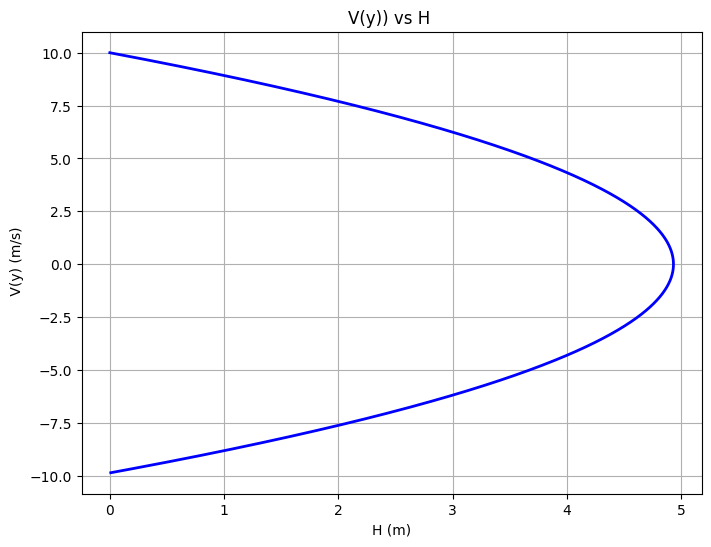

Maximum height reached: 4.9343 meters
Time to reach maximum height: 0.9900 seconds


In [107]:
#question 5:
def vertical_motion_system(t, y):
    # y = [height, velocity_y] 
    h,vy =y #unpack
    g = 10 #gravity
    gamma = 0.02  #air resistance 
    
    dhdt = vy
    dvydt = -g - gamma * vy  
    return [dhdt, dvydt]

# initial cond.
v0_vertical = 10  #up
initial_conditions = [0, v0_vertical]

t_vals, solution = ad.ODEs.rk4_system_solver(vertical_motion_system, initial_conditions, 0, 2.5, 0.001)
heights = [sol[0] for sol in solution] #extracted h
velocities = [sol[1] for sol in solution] #extracted v

max_height = max(heights) #maximum h reached
max_height_idx = heights.index(max_height)
max_height_time = t_vals[max_height_idx]

valid_data = [(h, v) for h, v in zip(heights, velocities) if h >= 0]    #taking positive height and velo. data!
if valid_data:
    h_valid, v_valid = zip(*valid_data)
    #plot
    plt.figure(figsize=(8,6))
    plt.plot(h_valid, v_valid, 'b-', linewidth=2)
    plt.xlabel('H (m)')
    plt.ylabel(' V(y) (m/s)')
    plt.title('V(y)) vs H ')
    plt.grid(True)
    plt.show()
    
print(f"Maximum height reached: {max_height:.4f} meters")
print(f"Time to reach maximum height: {max_height_time:.4f} seconds")

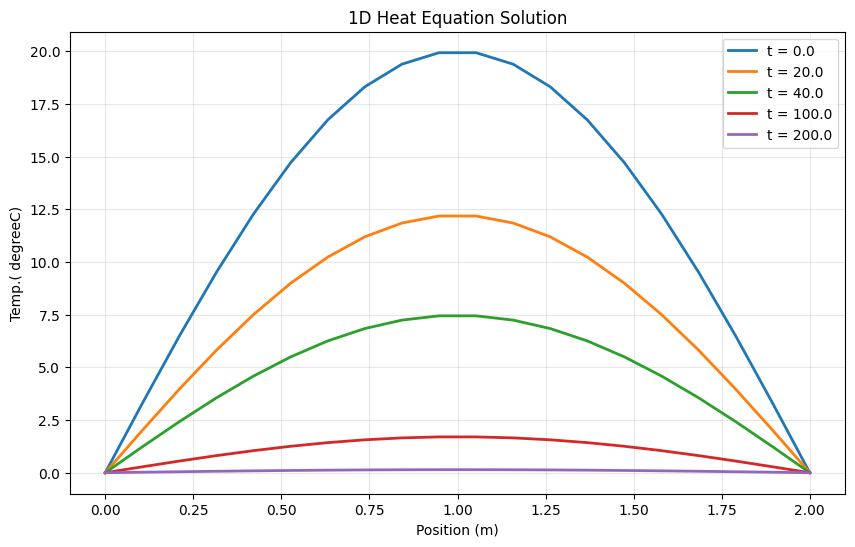

Grid points: 20, Time steps: 2001
Initial temperature at center: 19.93degC
Final temperature at center: 0.14dgC


In [108]:
#question 6:
def heat_equation_solver():
    
    L=2.0  #length
    nx=20  # points
    dx=L/(nx-1)
    
    # initial condition
    x_points = [i * dx for i in range(nx)]
    u_initial = [20 * math.sin(math.pi * x / L) for x in x_points]
    
    def heat_system(t, u_vec): #define sysytem
        alpha = 0.01  
        dudt = [0.0] * nx
        
        # boundary conditions
        dudt[0] = 0
        dudt[nx-1] = 0
        
        #interior-points
        for i in range(1, nx-1):
            d2u_dx2 = (u_vec[i+1] - 2*u_vec[i] + u_vec[i-1]) / (dx**2)
            dudt[i] = alpha * d2u_dx2
            
        return dudt
    
    t_final=200  
    dt=0.1
    t_vals, solution = ad.ODEs.rk4_system_solver(heat_system, u_initial, 0, t_final, dt)
    
    # plot
    plt.figure(figsize=(10,6))
    time_steps = len(solution)
    plot_indices = [0, time_steps//10, time_steps//5, time_steps//2, time_steps-1]
    
    for idx in plot_indices:
        if idx < len(solution):
            time_label = f't = {t_vals[idx]:.1f}'
            plt.plot(x_points, solution[idx], label=time_label, linewidth=2)
    
    plt.xlabel('Position (m)')
    plt.ylabel('Temp.( degreeC)')
    plt.title('1D Heat Equation Solution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return solution,x_points,t_vals

u_solution,x_grid,time_grid=heat_equation_solver()
print(f"Grid points: {len(x_grid)}, Time steps: {len(u_solution)}")
print(f"Initial temperature at center: {u_solution[0][len(x_grid)//2]:.2f}degC")
print(f"Final temperature at center: {u_solution[-1][len(x_grid)//2]:.2f}dgC")

Solved for polynomial coefficients: [0.254629507211546, -1.193759213809226, -0.4572554123829645, -0.8025653910658191, 0.013239427477395415]


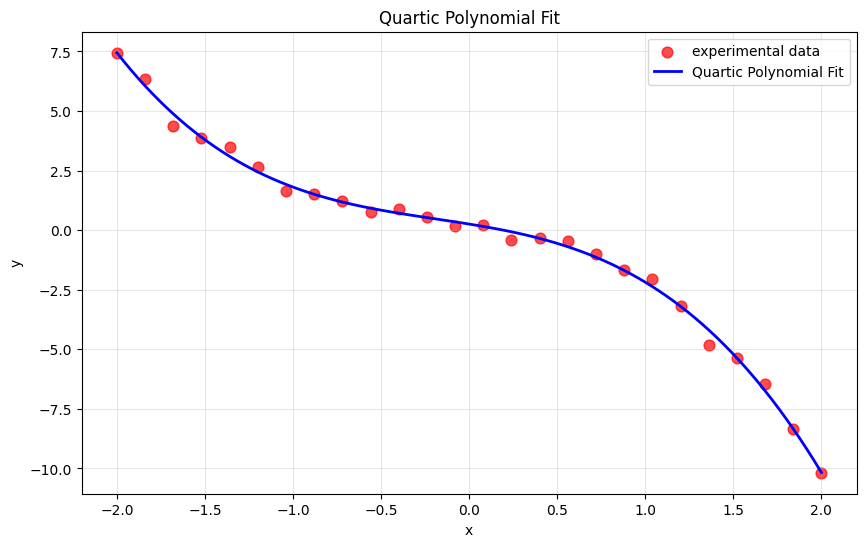


Quartic polynomial coeff.
  a0 = 0.254630
  a1 = -1.193759
  a2 = -0.457255
  a3 = -0.802565
  a4 = 0.013239


In [ ]:
#question 7:
filepath = '/Users/adityaagrawal/clonedrepo/COMPUTATIONAL_PHYSICS/LABWORK/ENDSEMs/esem4fit.txt'

data=[]  #readd!
with open(filepath, 'r') as file:
    for line in file:
        line = line.strip()
        if line:  # skip empty lines
            # handle both tab and space separated data
            values = line.split('\t') if '\t' in line else line.split()
            if len(values) >= 2:
                try:
                    x_val = float(values[0])
                    y_val = float(values[1])
                    data.append([x_val, y_val])
                except ValueError:
                    continue  

x_data=[row[0] for row in data] #extractingg...
y_data=[row[1] for row in data]

n = len(x_data)
A = [[x_data[i]**j for j in range(5)] for i in range(n)]  # n×5 matrix for 5 coefficients

AT = ad.MatrixOperations.transposee(A)  #computed A-transpose

AT_A = ad.MatrixOperations.multiplyy(AT, A) # computed A^T.A

AT_y = [sum(AT[i][j] * y_data[j] for j in range(n)) for i in range(5)]  #take dott A^T.y

# solve by Gauss-Jordan
coeffs = ad.LinearSystems.gauss_jordan(AT_A, AT_y)
print(f"Solved for polynomial coefficients: {coeffs}")

#for curve genrating
x_fit = [min(x_data) + i * (max(x_data) - min(x_data))/100 for i in range(101)]
y_fit = [sum(coeffs[j] * x**j for j in range(5)) for x in x_fit]

#PLOTTING!!!
plt.figure(figsize=(10,6))
plt.scatter(x_data, y_data, color='red', label='experimental data', s=60, alpha=0.7)
plt.plot(x_fit, y_fit, 'b-', linewidth=2, label='Quartic Polynomial Fit')
plt.xlabel('x' )
plt.ylabel('y') 
plt.title('Quartic Polynomial Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("\nQuartic polynomial coeff.") #final result!
for i, coeff in enumerate(coeffs):
    print(f"  a{i} = {coeff:.6f}")

